# 필요 라이브러리 불러오기

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.family'] ='Malgun Gothic'
# plt.rcParams['font.family'] ='AppleGothic'

plt.rcParams['axes.unicode_minus'] =False

import seaborn as sns


from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 데이터 불러오기

In [2]:
from pathlib import Path
import tarfile
import urllib.request


def load_housing_data():
    tarball_path = Path('datasets/housing.tgz')
    if not tarball_path.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://github.com/ageron/data/raw/main/housing.tgz'
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path='datasets')
    return pd.read_csv(Path('datasets/housing/housing.csv'))


housing = load_housing_data()

In [3]:
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# 데이터 처리

## 데이터 확인

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 결측치 확인

In [5]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

-> total_bedrooms 결측치 처리

1. drop
2. 평균값으로 넣기
3. 주택 나이에 맞게 넣기?

In [6]:
# 방법 1. 결측치 drop
# housing = housing.dropna()
# housing = housing.reset_index()

# 방법 2. 평균값으로 넣기
# housing['total_bedrooms'] = housing['total_bedrooms'].fillna(housing['total_bedrooms'].mean())

In [7]:
# 방법 3. 주택 나이에 따른 전체 침실 수로 넣기
# 결측치 뺀 후 주택 나이에 따른 전체 침실 수의 평균 값
housing_drop = housing.dropna()
housing_drop = housing_drop.reset_index()
housing_gb = housing_drop.groupby('housing_median_age')['total_bedrooms'].mean().to_frame()
housing_gb = housing_gb.reset_index() 
housing_gb['total_bedrooms'] = housing_gb['total_bedrooms'].round(0)
dic = dict(zip(housing_gb['housing_median_age'], housing_gb['total_bedrooms']))

# null값인 인덱스
ind_lst = list(housing[housing['total_bedrooms'].isnull()].index)
ind_lst[:5]

[182, 327, 366, 477, 495]

In [8]:
for ind in ind_lst:
    if ind in list(housing.index):
        housing.loc[ind, 'total_bedrooms'] = dic[housing.loc[ind]['housing_median_age']]

In [9]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

## 이상치 확인

In [10]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.740552,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.504408,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,645.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<Axes: >

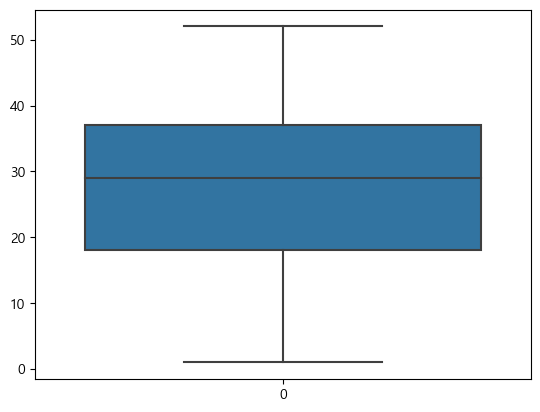

In [11]:
sns.boxplot(housing['housing_median_age']) 

<Axes: >

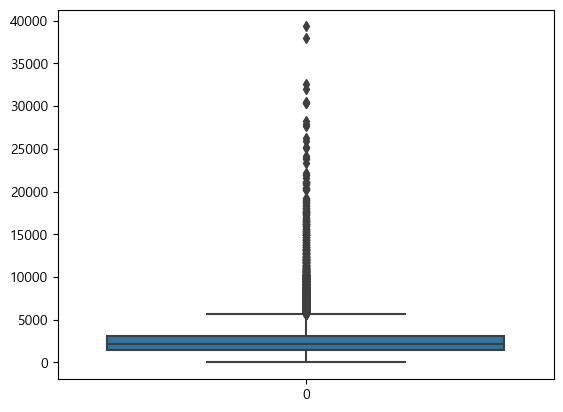

In [12]:
sns.boxplot(housing['total_rooms'])

<Axes: >

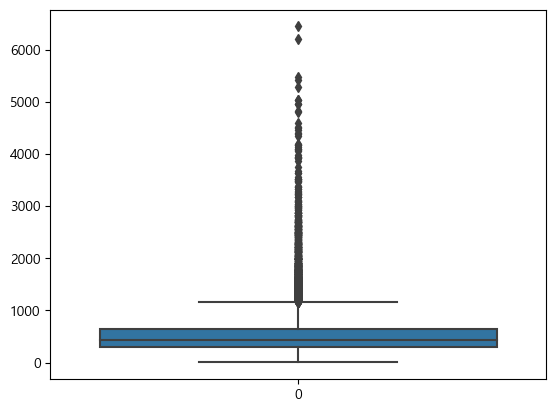

In [13]:
sns.boxplot(housing['total_bedrooms']) 

<Axes: >

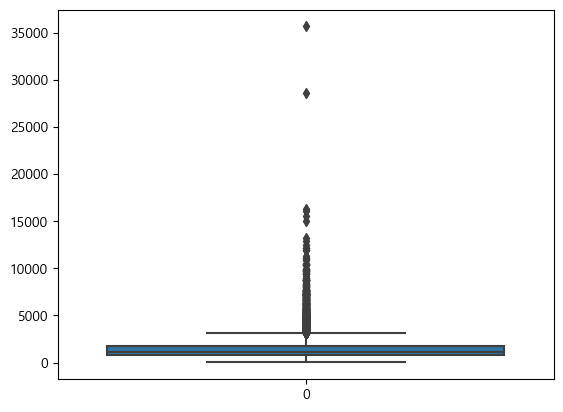

In [14]:
sns.boxplot(housing['population']) 

<Axes: >

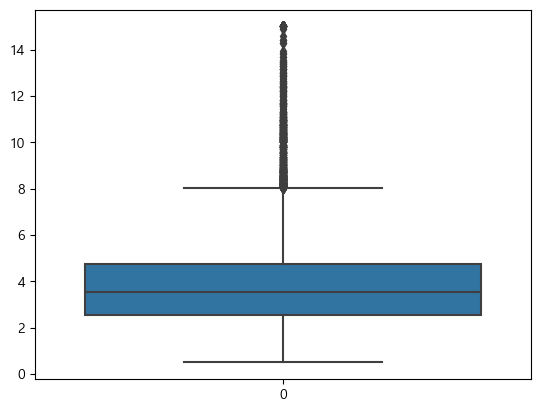

In [15]:
sns.boxplot(housing['median_income']) 

<Axes: >

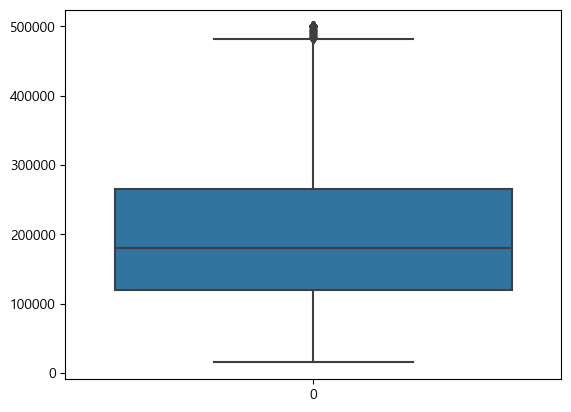

In [16]:
sns.boxplot(housing['median_house_value']) 

In [17]:
# def get_outlier(df, col):
#     quantile_25 = df[col].quantile(0.25)
#     quantile_75 = df[col].quantile(0.75)
    
#     IQR = quantile_75 - quantile_25
#     IQR_weight = IQR * 1.5
    
    
#     lowest = quantile_25 - IQR_weight
#     highest = quantile_75 + IQR_weight
    
#     outlier_idx = df[col][(df[col] < lowest) | (df[col] > highest)].index
#     return outlier_idx


# oulier_idx = get_outlier(housing, 'total_rooms')
# housing.drop(oulier_idx, axis=0, inplace=True)
# oulier_idx = get_outlier(housing, 'total_bedrooms')
# housing.drop(oulier_idx, axis=0, inplace=True)
# oulier_idx = get_outlier(housing, 'population')
# housing.drop(oulier_idx, axis=0, inplace=True)
# oulier_idx = get_outlier(housing, 'households')
# housing.drop(oulier_idx, axis=0, inplace=True)

# housing = housing.reset_index(drop = True)
# housing

## 명목형 처리

In [18]:
col_num = list(housing.describe().columns)
col_cat = ['ocean_proximity']

In [19]:
df_num = housing[col_num]
df_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


In [20]:
ohe = OneHotEncoder(handle_unknown = 'ignore')
ohe.fit(housing[col_cat])

ohe_res = ohe.transform(housing[col_cat])
df_ohe = pd.DataFrame(ohe_res.todense(), columns = ohe.get_feature_names_out())

df = pd.concat([df_num, df_ohe], axis = 1)
df

OneHotEncoder(handle_unknown='ignore')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,0.0,1.0,0.0,0.0,0.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,0.0,1.0,0.0,0.0,0.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,0.0,1.0,0.0,0.0,0.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,0.0,1.0,0.0,0.0,0.0


## 새로운 컬럼 추가

In [21]:
df['density_pop'] = df['households'] / (df['population'] * 100)
df['rooms_per_house'] = df['total_rooms'] / df['households']*100
df['rooms_bedrooms'] = df['total_rooms'] / df['total_bedrooms']
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,density_pop,rooms_per_house,rooms_bedrooms
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,0.0,1.0,0.0,0.003913,698.412698,6.821705
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,0.0,1.0,0.0,0.004740,623.813708,6.418626
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,0.0,1.0,0.0,0.003569,828.813559,7.721053
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,0.0,1.0,0.0,0.003925,581.735160,5.421277
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,0.0,1.0,0.0,0.004584,628.185328,5.810714


## 스케일러

In [22]:
col_num = col_num + ['density_pop', 'rooms_per_house', 'rooms_bedrooms']
col_num

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'density_pop',
 'rooms_per_house',
 'rooms_bedrooms']

In [23]:
scaler = MinMaxScaler()
scaler.fit(df[col_num])

df[col_num] = scaler.transform(df[col_num])

MinMaxScaler()

## 변수 중요도 확인

In [24]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [25]:
model = RandomForestRegressor(random_state = 42)
#                               n_estimators = 100,
#                               max_depth = 12,
#                               min_samples_leaf = 8,
#                               min_samples_split = 8,
#                               n_jobs = -1)
model.fit(X, y)

feature_importances = model.feature_importances_
feature_importances

RandomForestRegressor(random_state=42)

array([6.04099550e-02, 5.85070231e-02, 4.32495224e-02, 1.23415393e-02,
       1.18306062e-02, 1.14338686e-02, 1.03750111e-02, 4.75071851e-01,
       1.21963873e-03, 1.40150340e-01, 1.41899706e-04, 7.11228779e-04,
       2.54282011e-03, 1.21078594e-01, 2.72695550e-02, 2.36665469e-02])

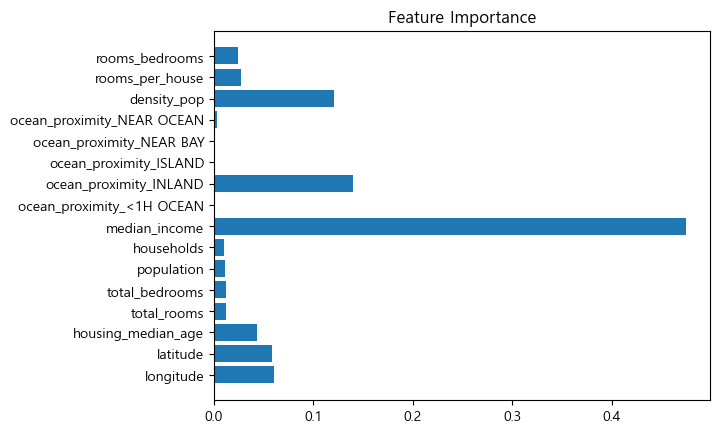

In [26]:
features = X.columns
plt.barh(features, feature_importances)
plt.title("Feature Importance")
plt.show();

낮은 변수명은 삭제

In [27]:
X = df.drop(['ocean_proximity_<1H OCEAN',
                'ocean_proximity_NEAR BAY',
                'ocean_proximity_ISLAND',
                'ocean_proximity_NEAR OCEAN', 
                'median_house_value'               
               ], axis=1)

y = df['median_house_value']

## 데이터 나누기

In [28]:
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size = 0.3)

In [29]:
X_tr.shape, X_val.shape, y_tr.shape, y_val.shape

((14448, 12), (6192, 12), (14448,), (6192,))

# 모델

## RandomForestRegressor

In [30]:
rfr_model = RandomForestRegressor(random_state = 42)
#                               n_estimators = 100,
#                               max_depth = 12,
#                               min_samples_leaf = 8,
#                               min_samples_split = 8,
#                               n_jobs = -1)
rfr_model.fit(X_tr, y_tr)

RandomForestRegressor(random_state=42)

In [31]:
pred_tr = rfr_model.predict(X_tr)
pred_val = rfr_model.predict(X_val)

print('r2 tr : ', r2_score(y_tr, pred_tr))
print('r2 val : ', r2_score(y_val, pred_val))

print('rmse tr : ', mean_squared_error(y_tr, pred_tr, squared = False))
print('rmse val : ', mean_squared_error(y_val, pred_val, squared = False))

r2 tr :  0.9737361000041997
r2 val :  0.8048979771478546
rmse tr :  0.03866316121388226
rmse val :  0.10441950770039639


In [32]:
whole_data = rfr_model.predict(X)

In [33]:
X['predicted price'] = whole_data
X['median_house_value'] = df['median_house_value']

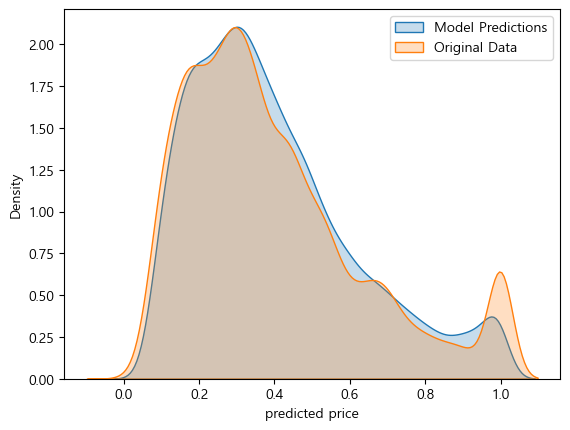

In [34]:
sns.kdeplot(data=X, x=X['predicted price'], label='Model Predictions', fill=True)
sns.kdeplot(data=X, x=X['median_house_value'], label='Original Data', fill=True)
plt.legend();

In [35]:
final_predictions = rfr_model.predict(X_val)

final_rmse = mean_squared_error(y_val, final_predictions, squared = False)
final_rmse

0.10441950770039639

## LGBMRegressor

In [36]:
# !pip install lightgbm

In [39]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(n_estimators = 100)
evals = [(X_val, y_val)]
lgbm_model.fit(X_tr,y_tr, eval_metric="logloss", eval_set=evals)

pred_tr = lgbm_model.predict(X_tr)
pred_val = lgbm_model.predict(X_val)

print('r2 tr : ', r2_score(y_tr, pred_tr))
print('r2 val : ', r2_score(y_val, pred_val))

print('rmse tr : ', mean_squared_error(y_tr, pred_tr, squared = False))
print('rmse val : ', mean_squared_error(y_val, pred_val, squared = False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000502 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2604
[LightGBM] [Info] Number of data points in the train set: 14448, number of used features: 12
[LightGBM] [Info] Start training from score 0.395539


LGBMRegressor()

r2 tr :  0.8903434852099867
r2 val :  0.8268138183558629
rmse tr :  0.07900143347469125
rmse val :  0.09838012584871662


In [40]:
X = df.drop(['ocean_proximity_<1H OCEAN',
                'ocean_proximity_NEAR BAY',
                'ocean_proximity_ISLAND',
                'ocean_proximity_NEAR OCEAN', 
                'median_house_value'               
               ], axis=1)

y = df['median_house_value']

whole_data = lgbm_model.predict(X)

In [41]:
X['predicted price'] = whole_data
X['median_house_value'] = df['median_house_value']

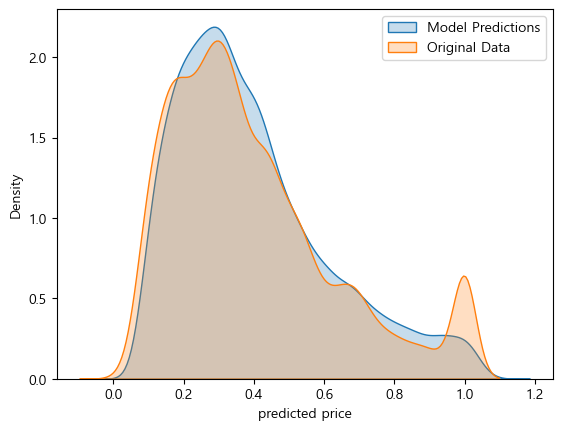

In [42]:
sns.kdeplot(data=X, x=X['predicted price'], label='Model Predictions', fill=True)
sns.kdeplot(data=X, x=X['median_house_value'], label='Original Data', fill=True)
plt.legend();

In [43]:
final_predictions = lgbm_model.predict(X_val)

final_rmse = mean_squared_error(y_val, final_predictions, squared = False)
final_rmse

0.09838012584871662

## XGBRegressor

In [44]:
# !pip install xgboost

In [45]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100)
xgb_model.fit(X_tr,y_tr)

pred_tr = xgb_model.predict(X_tr)
pred_val = xgb_model.predict(X_val)

print('r2 tr : ', r2_score(y_tr, pred_tr))
print('r2 val : ', r2_score(y_val, pred_val))

print('rmse tr : ', mean_squared_error(y_tr, pred_tr, squared = False))
print('rmse val : ', mean_squared_error(y_val, pred_val, squared = False))

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

r2 tr :  0.9535172537970013
r2 val :  0.8235070394530695
rmse tr :  0.05143558000409044
rmse val :  0.0993149090654605


In [46]:
X = df.drop(['ocean_proximity_<1H OCEAN',
                'ocean_proximity_NEAR BAY',
                'ocean_proximity_ISLAND',
                'ocean_proximity_NEAR OCEAN', 
                'median_house_value'               
               ], axis=1)

y = df['median_house_value']

whole_data = xgb_model.predict(X)

In [47]:
X['predicted price'] = whole_data
X['median_house_value'] = df['median_house_value']

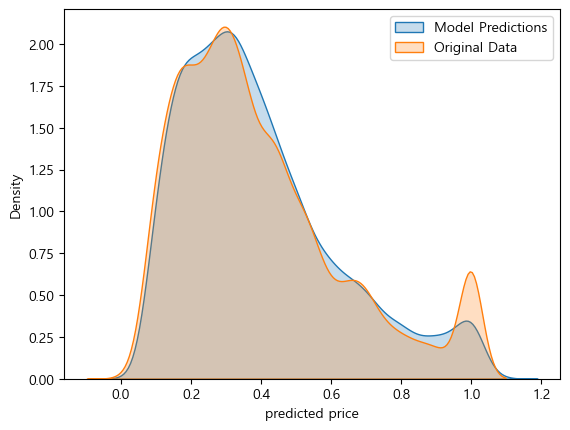

In [48]:
sns.kdeplot(data=X, x=X['predicted price'], label='Model Predictions', fill=True)
sns.kdeplot(data=X, x=X['median_house_value'], label='Original Data', fill=True)
plt.legend();

In [49]:
final_predictions = xgb_model.predict(X_val)

final_rmse = mean_squared_error(y_val, final_predictions, squared = False)
final_rmse

0.0993149090654605